In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return x ** 2

In [3]:
f(3.0)

9.0

In [4]:
x_values = np.arange(-5,5.25,0.25)
y_values = f(x_values)

In [5]:
y_values

array([25.    , 22.5625, 20.25  , 18.0625, 16.    , 14.0625, 12.25  ,
       10.5625,  9.    ,  7.5625,  6.25  ,  5.0625,  4.    ,  3.0625,
        2.25  ,  1.5625,  1.    ,  0.5625,  0.25  ,  0.0625,  0.    ,
        0.0625,  0.25  ,  0.5625,  1.    ,  1.5625,  2.25  ,  3.0625,
        4.    ,  5.0625,  6.25  ,  7.5625,  9.    , 10.5625, 12.25  ,
       14.0625, 16.    , 18.0625, 20.25  , 22.5625, 25.    ])

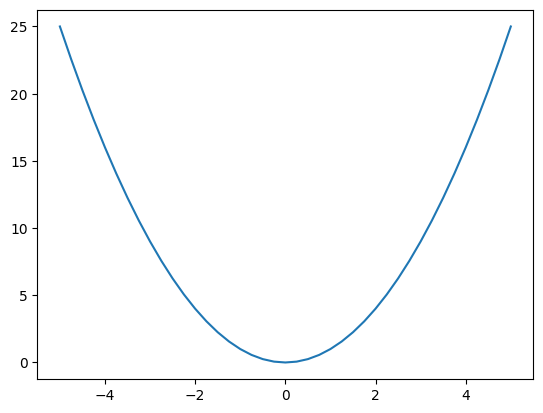

In [6]:
plt.plot(x_values, y_values)

In [7]:
h = 0.000000001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
d2 = (a)*(b) + (c+h)
slope = (d2 - d1)/h
print(f'd1: {d1}; d2: {d2}')
print(slope)

d1: 4.0; d2: 4.000000001
1.000000082740371


In [8]:
class Value:
    """
    Takes in a single scalar value and stores it.
    """ 
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), "*")
        return out

In [9]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label="L"


In [10]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

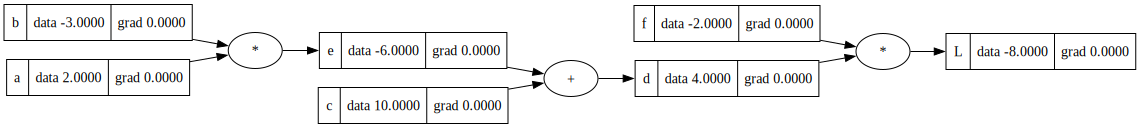

In [11]:
draw_dot(L)